In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [2]:
N = 10
wd = 0.6365091993031
wm = 1.0
freq_dis = 0.00
indv_qubit = False
t_max = 200
tlist = np.linspace(0, t_max, 400)
reals = 100
rand = True
z_ham = False
dis = 0.3

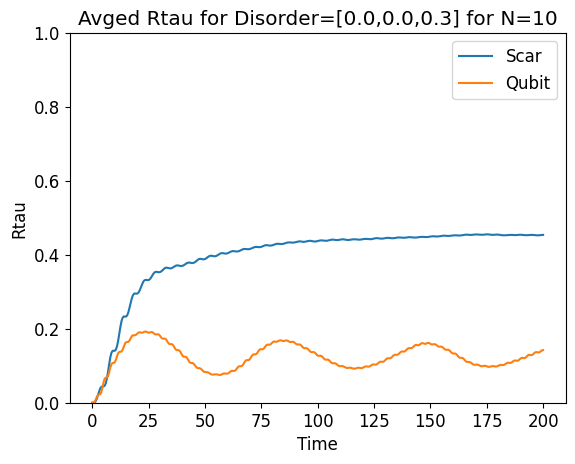

C:\Users\idden\AppData\Local\Temp\ipykernel_29540\2539181180.py:44: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, xfull_scar / xfull_qubit)


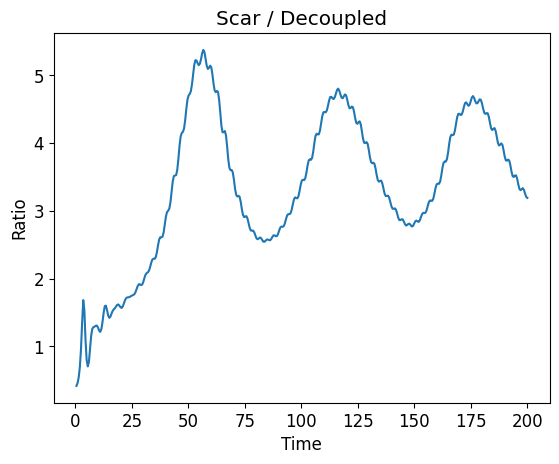

In [3]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

full_scar = 0
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[dz, dy, dx], random_seed=rand, indv_qubit=indv_qubit)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], random_seed=rand, indv_qubit=indv_qubit, sigz_ham=z_ham)
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

xfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, xfull_scar / xfull_qubit)
plt.show()

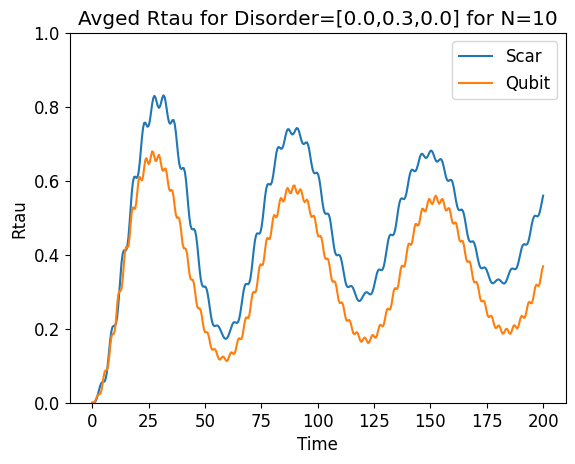

C:\Users\idden\AppData\Local\Temp\ipykernel_29540\1188833218.py:42: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, yfull_scar / yfull_qubit)


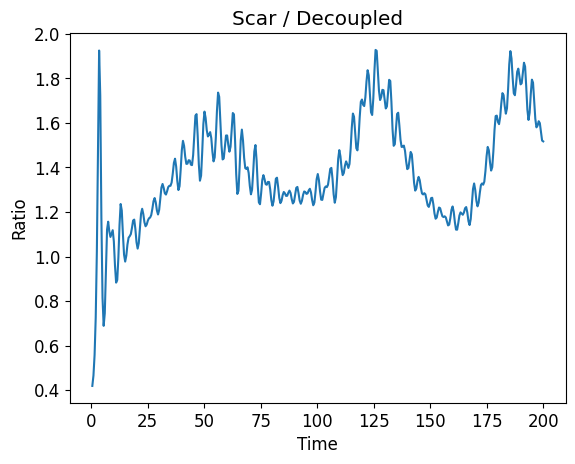

In [4]:
dz = 0.0
dy = dis
dx = 0.0

full_scar = 0
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[dz, dy, dx], random_seed=rand, indv_qubit=indv_qubit)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

yfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], random_seed=rand, indv_qubit=indv_qubit, sigz_ham=z_ham)
    qeigenvalues, qeigenstates = qH0.eigenstates()
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

yfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, yfull_scar, label="Scar")
plt.plot(tlist, yfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, yfull_scar / yfull_qubit)
plt.show()

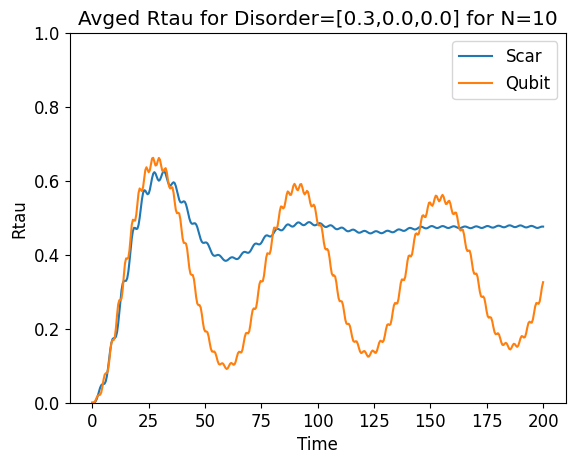

C:\Users\idden\AppData\Local\Temp\ipykernel_29540\1096073927.py:45: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, zfull_scar / zfull_qubit)


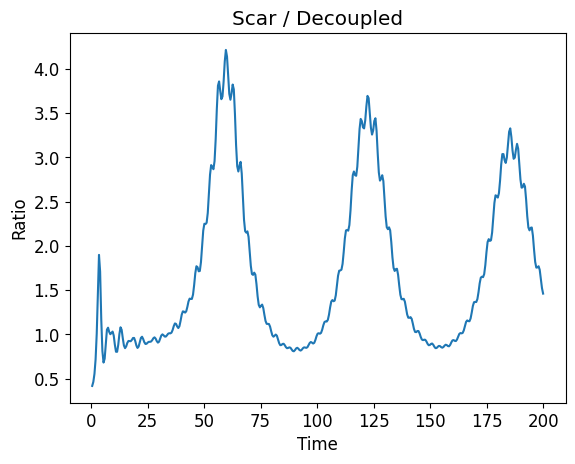

In [5]:
dz = dis
dy = 0.0
dx = 0.0

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

full_scar = 0
for _ in range(reals):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[dz, dy, dx], random_seed=rand, indv_qubit=indv_qubit)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

zfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], random_seed=rand, indv_qubit=indv_qubit, sigz_ham=z_ham)
    qeigenvalues, qeigenstates = qH0.eigenstates()
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

zfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, zfull_scar, label="Scar")
plt.plot(tlist, zfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, zfull_scar / zfull_qubit)
plt.show()

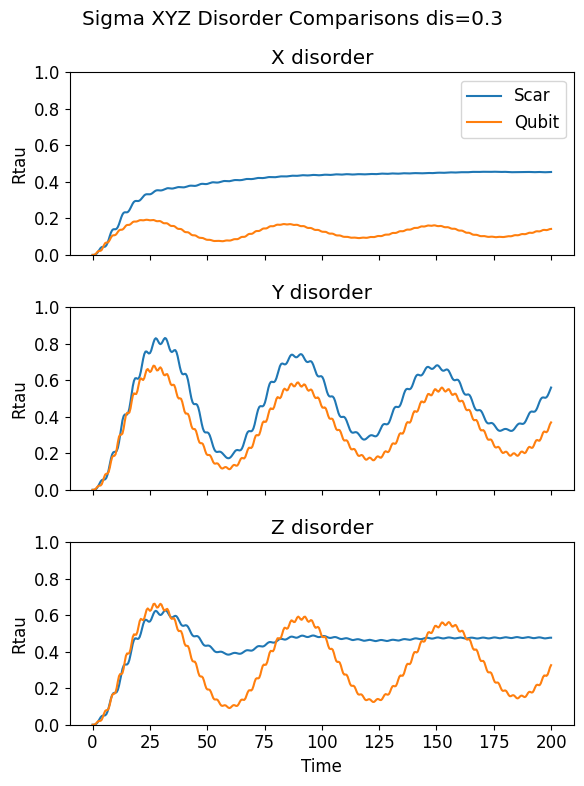

<Figure size 640x480 with 0 Axes>

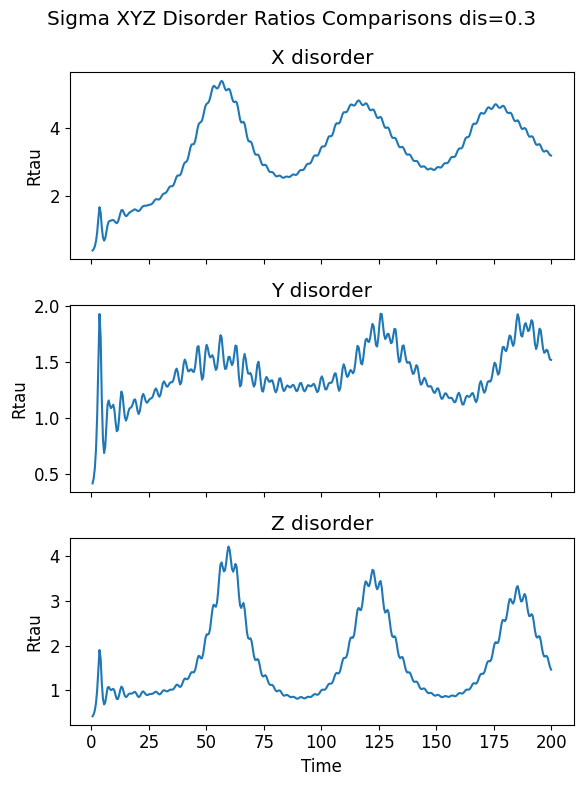

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Comparisons dis=0.3")

axs[0].plot(tlist, xfull_scar, label="Scar")
axs[0].plot(tlist, xfull_qubit, label="Qubit")
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")
axs[0].legend()

axs[1].plot(tlist, yfull_scar, label="Scar")
axs[1].plot(tlist, yfull_qubit, label="Qubit")
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist, zfull_scar, label="Scar")
axs[2].plot(tlist, zfull_qubit, label="Qubit")
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)
axs[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Ratios Comparisons dis=0.3")

axs[0].plot(tlist[1:], xfull_scar[1:] / xfull_qubit[1:])
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")

axs[1].plot(tlist[1:], yfull_scar[1:] / yfull_qubit[1:])
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist[1:], zfull_scar[1:] / zfull_qubit[1:])
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

plt.tight_layout()
plt.show()